In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style

from jupyfun import in_range

In [2]:
%matplotlib inline

auto_plot_style()

In [3]:
path = Path("/home/gonzalo/data/COLINA/preamp_scope_hot_v0/")
signalpath = path / "Signal"
a1path = path / "A1"
a2path = path / "A2"
a3path = path / "A3"
a4path = path / "A4"
s2path = path / "2S"
impath = path / "ImpedanceMatch"

In [37]:
def read(filename):
    return np.loadtxt(filename, skiprows=5, delimiter=",").T

def integrate_signal(t, a, t0, t1):
    baseline = np.mean(a[:a.size//3])
    signal   = np.sum (a[in_range(t, t0*1e-6, t1*1e-6)] - baseline)
    return signal * (t[1]-t[0])

def read_and_integrate(filename, t0, t1):
    return integrate_signal(*read(filename), t0, t1)

def difference(filename1, filename2):
    t1, a1 = read(filename1)
    t2, a2 = read(filename2)
    return t1, a2 - a1

def signal_to_noise(t, a, blinewindow, signalwindow):
    blinewindow  = np.array(blinewindow)  * 1e-6
    signalwindow = np.array(signalwindow) * 1e-6
    noise    = np.std (a[in_range(t, *blinewindow )])
    baseline = np.mean(a[in_range(t, *blinewindow )])
    signal   = np.mean(a[in_range(t, *signalwindow)] - baseline)
    return signal/noise

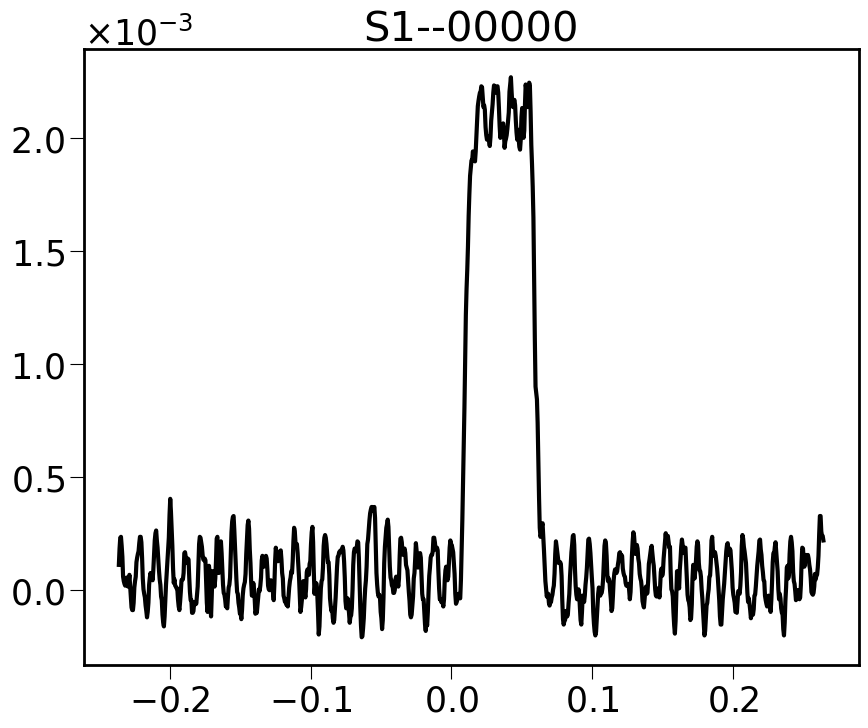

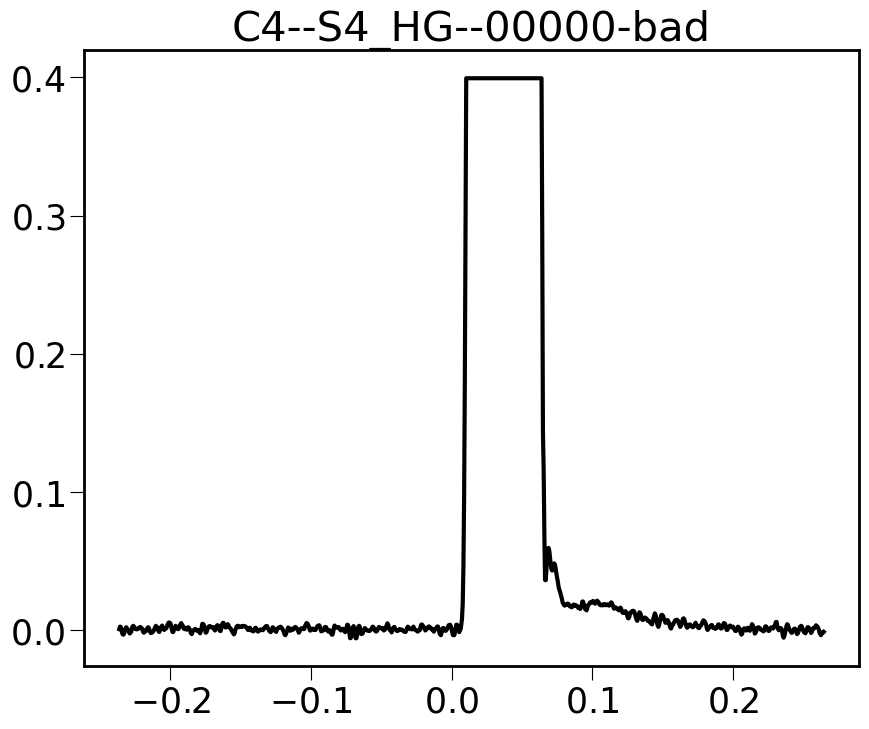

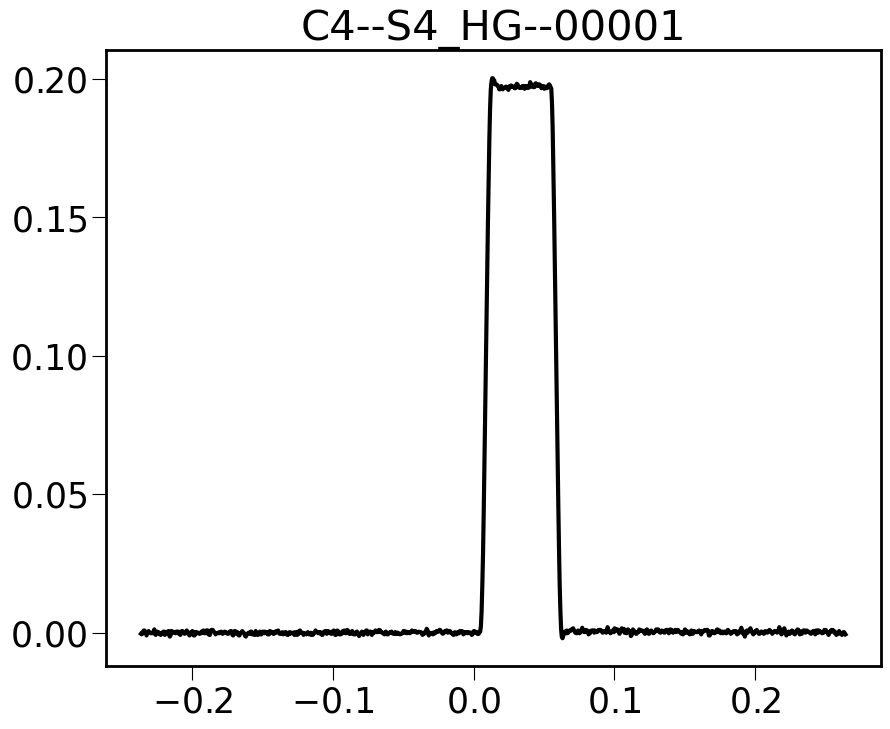

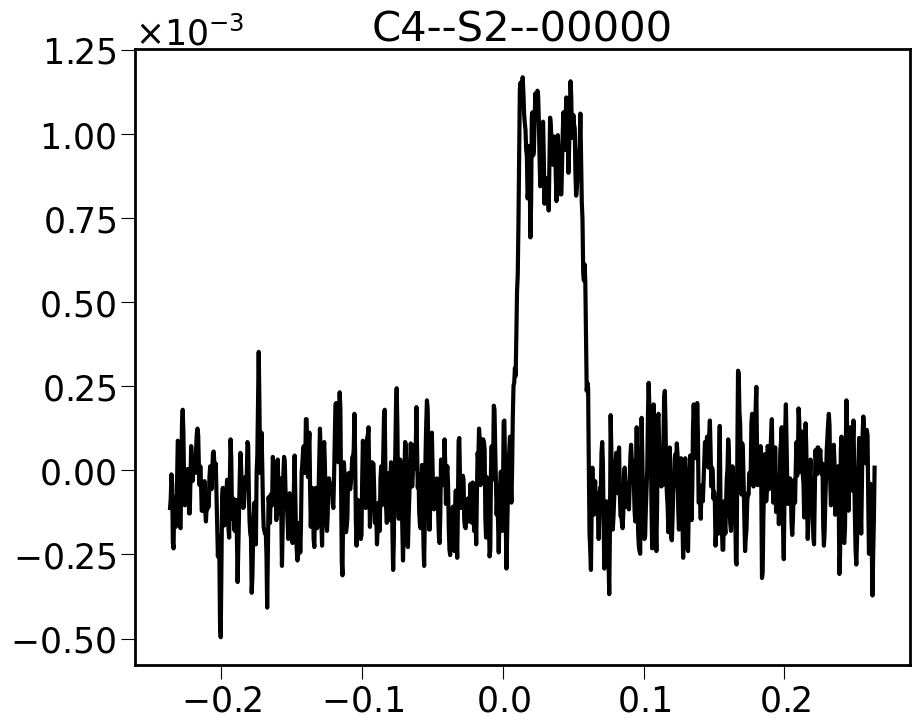

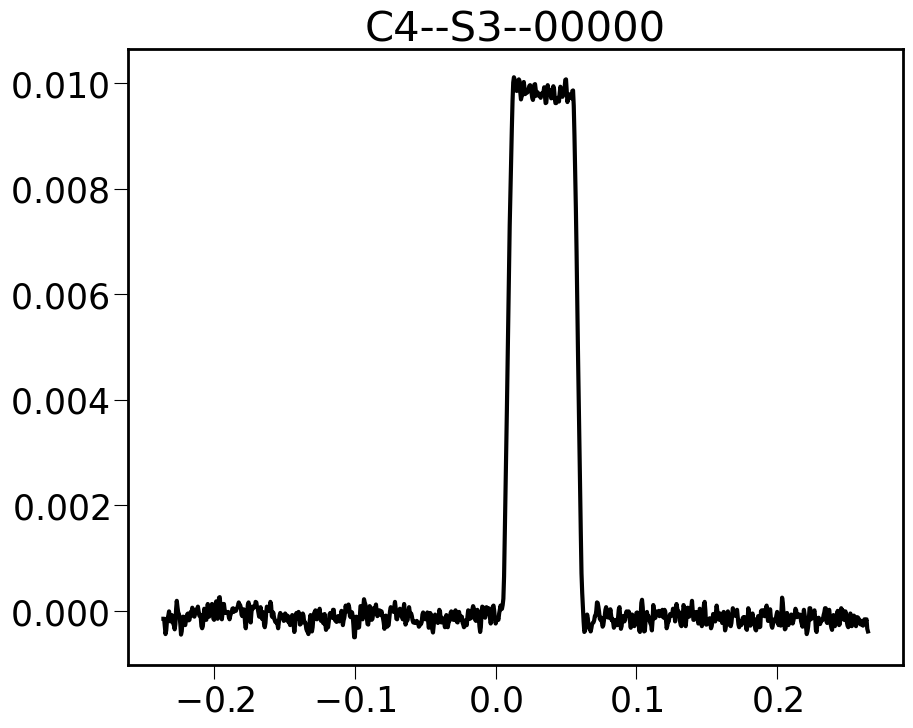

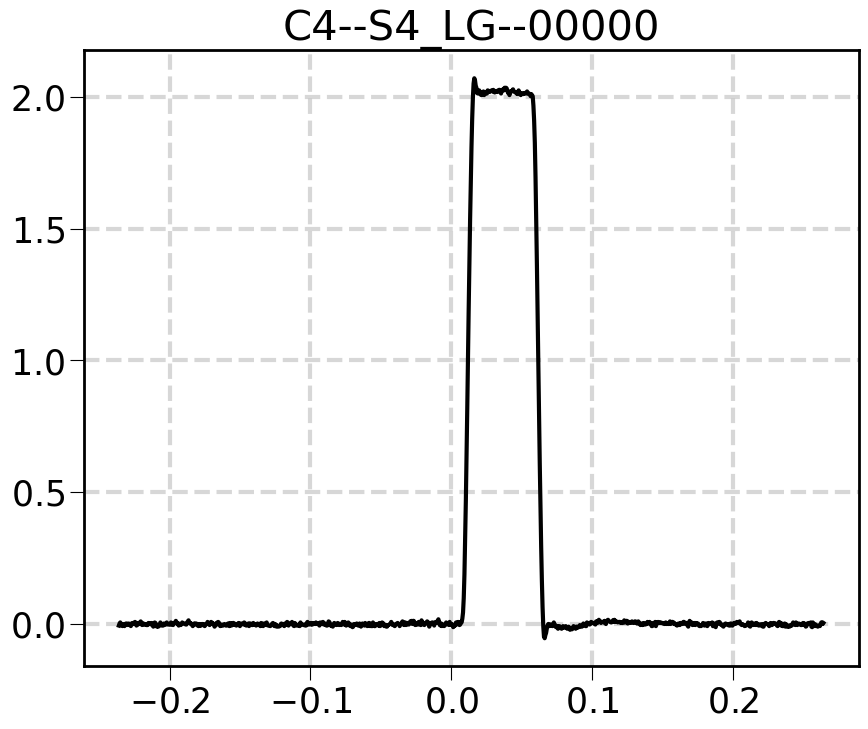

In [5]:
for filename in signalpath.glob("*"):
    t, a = read(filename)
    t *= 1e6
    plt.figure()
    plt.plot(t, a)
    plt.title(filename.stem)
plt.grid()

In [47]:
signalwindow = 0, 0.07
shapedwindow = 0, 0.15
blinewindow  = -0.3, -0.05

In [7]:
s1  = read_and_integrate(signalpath /        "S1--00000.csv", *signalwindow)
s2  = read_and_integrate(signalpath /    "C4--S2--00000.csv", *signalwindow)
s3  = read_and_integrate(signalpath /    "C4--S3--00000.csv", *signalwindow)
s4l = read_and_integrate(signalpath / "C4--S4_LG--00000.csv", *signalwindow)
s4h = read_and_integrate(signalpath / "C4--S4_HG--00001.csv", *signalwindow)
# in V·s

In [8]:
s1, s2, s3, s4l, s4h

(1.0075334131736751e-10,
 5.0466000000001124e-11,
 4.942685928143561e-10,
 1.0069852095808603e-07,
 9.859514371257182e-09)

In [9]:
signals_low  = np.array([s2, s3, s4l])
signals_high = np.array([s2, s3, s4h])

bias_low     = np.array([1, 10, 2000])
bias_high    = np.array([1, 10,  200])

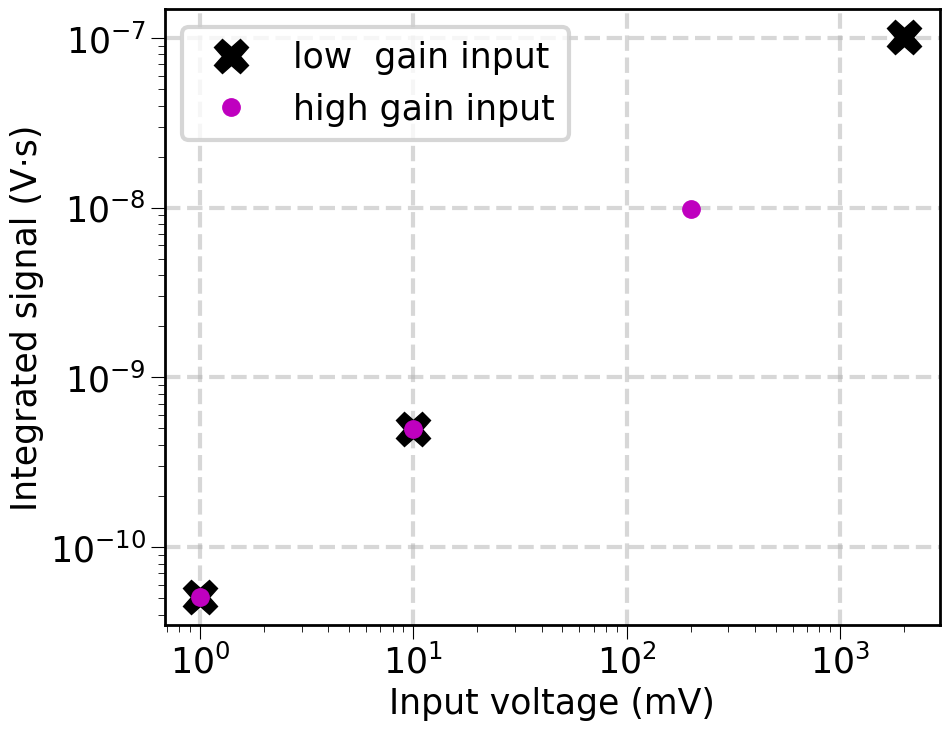

In [10]:
plt.plot(bias_low , signals_low , "Xk", label="low  gain input")
plt.plot(bias_high, signals_high, ".m", label="high gain input")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlabel("Input voltage (mV)")
plt.ylabel("Integrated signal (V·s)")
plt.grid()

# Low gain direct

In [38]:
a1 = []
n1 = []
for s in "s2 s3 s4".split():
    diff1   = a1path / f"C2--{s}_a1--00000.csv"
    diff2   = a1path / f"C3--{s}_a1--00000.csv"
    t, diff = difference(diff1, diff2)
    a1 = np.append(a1, integrate_signal(t, diff, *signalwindow))
    n1 = np.append(n1, signal_to_noise(t, diff, blinewindow, signalwindow))

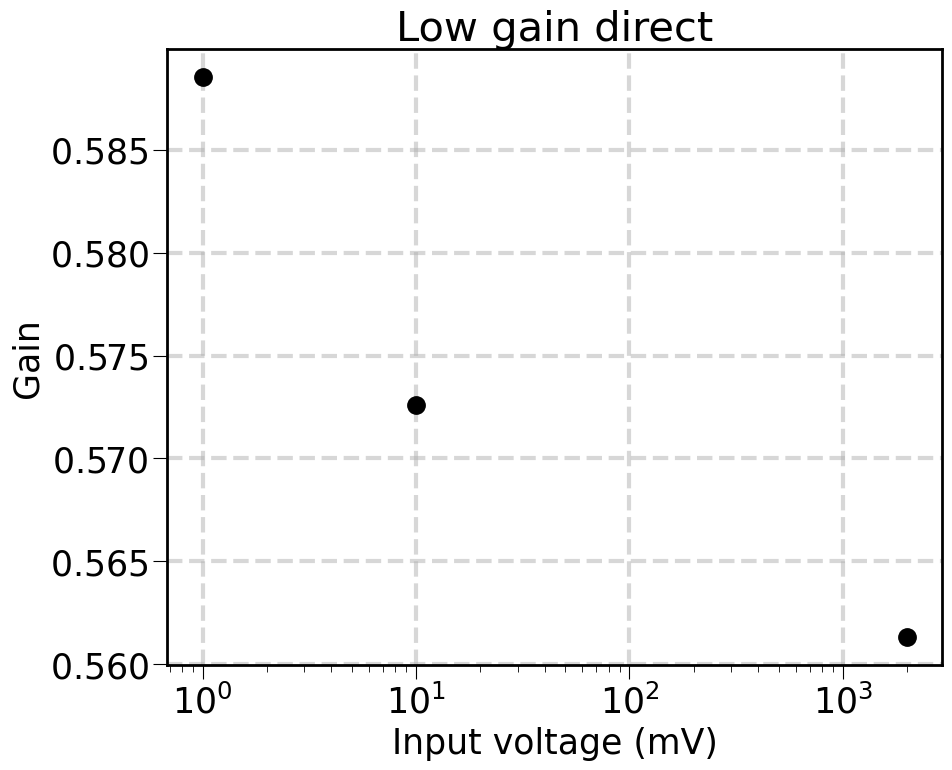

In [12]:
plt.plot(bias_low, a1/signals_low, "k.")
plt.xscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("Gain")
plt.title("Low gain direct")
plt.grid()

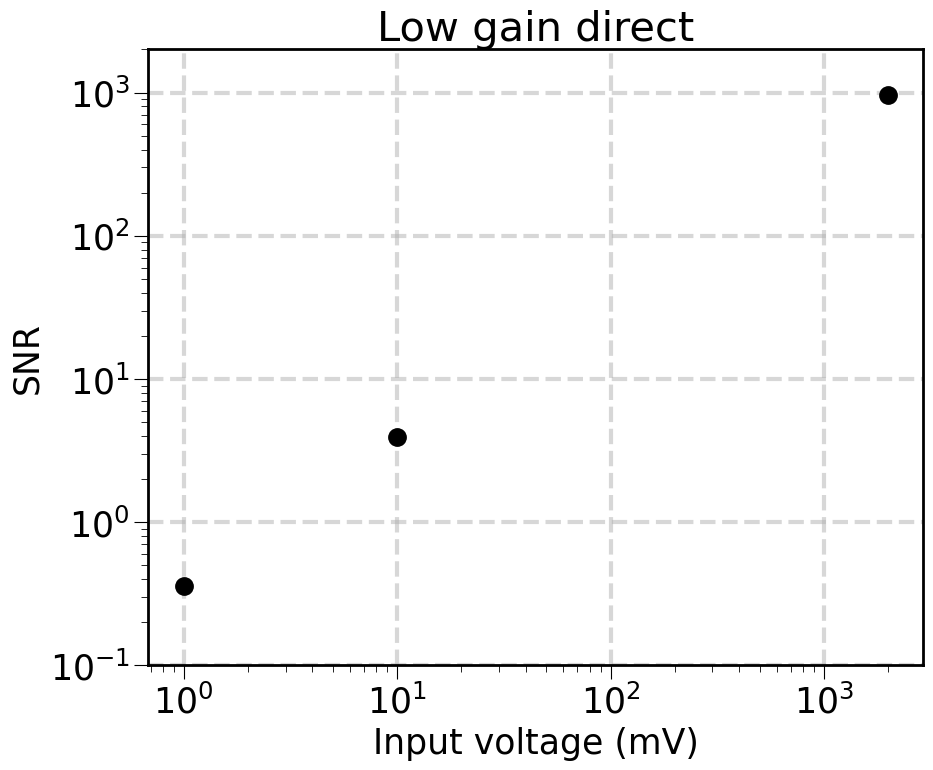

In [52]:
plt.plot(bias_low, n1, "k.")
plt.ylim(.1, 2e3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("SNR")
plt.title("Low gain direct")
plt.grid()

# High gain direct

In [46]:
a2 = []
n2 = []
for s in "s2 s3 s4".split():
    diff1   = a2path / f"C2--{s}_a2--00000.csv"
    diff2   = a2path / f"C3--{s}_a2--00000.csv"
    t, diff = difference(diff1, diff2)
    a2 = np.append(a2, integrate_signal(t, diff, *signalwindow))
    n2 = np.append(n2, signal_to_noise(t, diff, blinewindow, signalwindow))

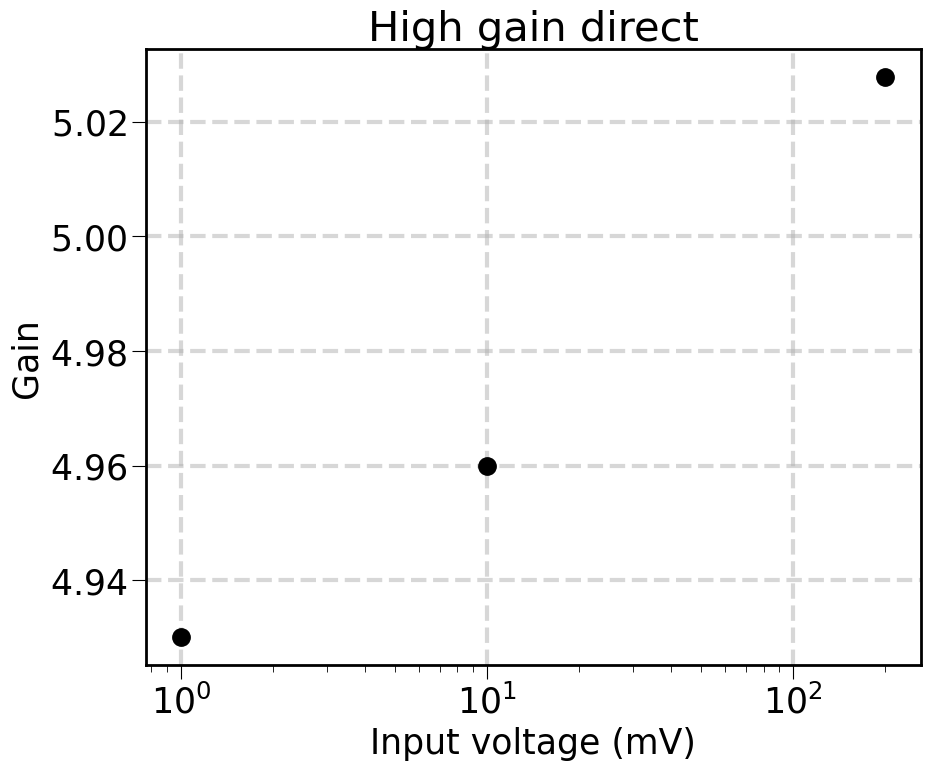

In [14]:
plt.plot(bias_high, a2/signals_high, "k.")
plt.xscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("Gain")
plt.title("High gain direct")
plt.grid()

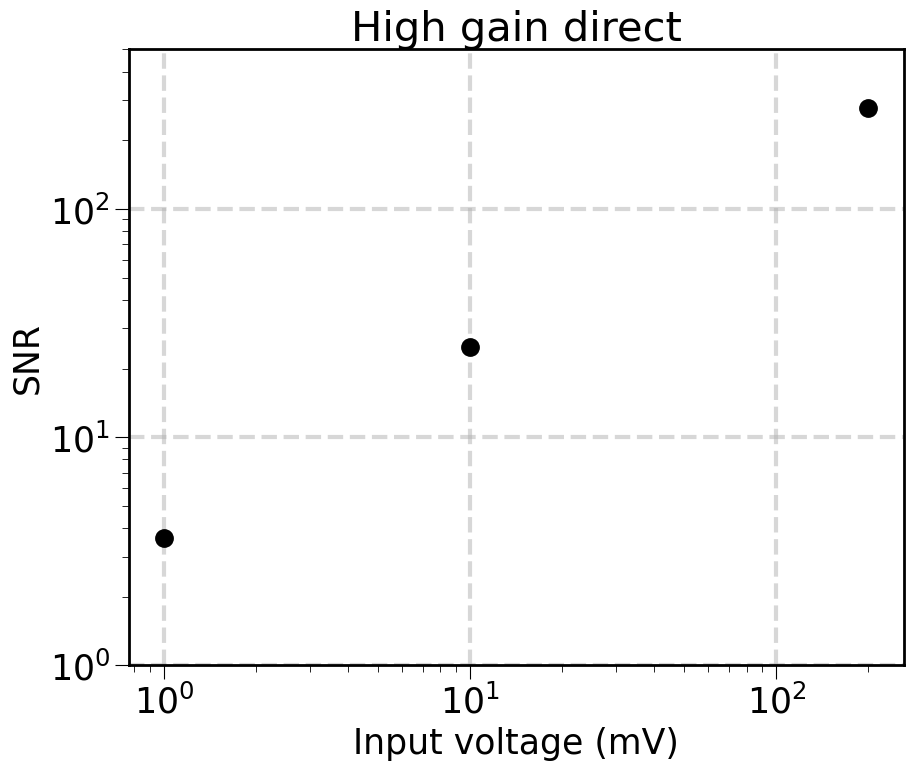

In [53]:
plt.plot(bias_high, n2, "k.")
plt.ylim(1, 5e2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("SNR")
plt.title("High gain direct")
plt.grid()

# Low gain multiplexer

In [55]:
a3_lg = []
a4_lg = []
n3_lg = []
n4_lg = []
for s in "s2 s3 s4".split():
    diff1   = a3path / f"C2--{s}_a3_lg--00000.csv"
    diff2   = a3path / f"C3--{s}_a3_lg--00000.csv"
    t, diff = difference(diff1, diff2)
    a3_lg = np.append(a3_lg, integrate_signal(t, diff, *signalwindow))
    n3_lg = np.append(n3_lg, signal_to_noise(t, diff, blinewindow, signalwindow))
    
    diff1   = a4path / f"C2--{s}_a4_lg--00000.csv"
    diff2   = a4path / f"C3--{s}_a4_lg--00000.csv"
    t, diff = difference(diff1, diff2)
    a4_lg = np.append(a4_lg, integrate_signal(t, diff, *signalwindow))
    n4_lg = np.append(n4_lg, signal_to_noise(t, diff, blinewindow, signalwindow))

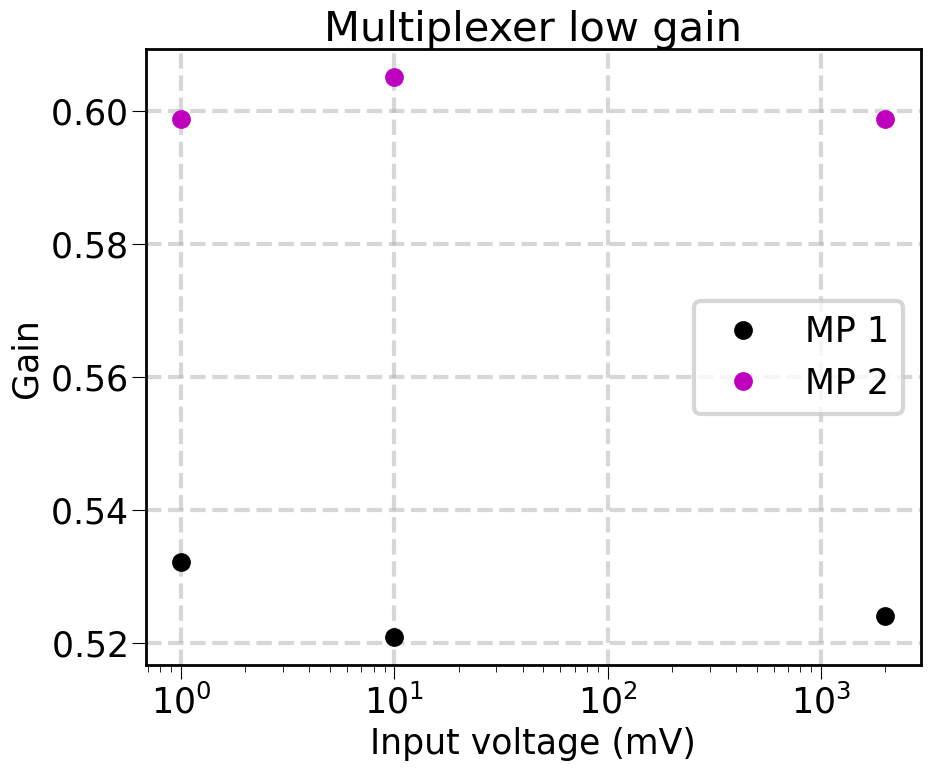

In [56]:
plt.plot(bias_low, a3_lg/signals_low, "k.", label="MP 1")
plt.plot(bias_low, a4_lg/signals_low, "m.", label="MP 2")
plt.xscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("Gain")
plt.title("Multiplexer low gain")
plt.legend()
plt.grid()

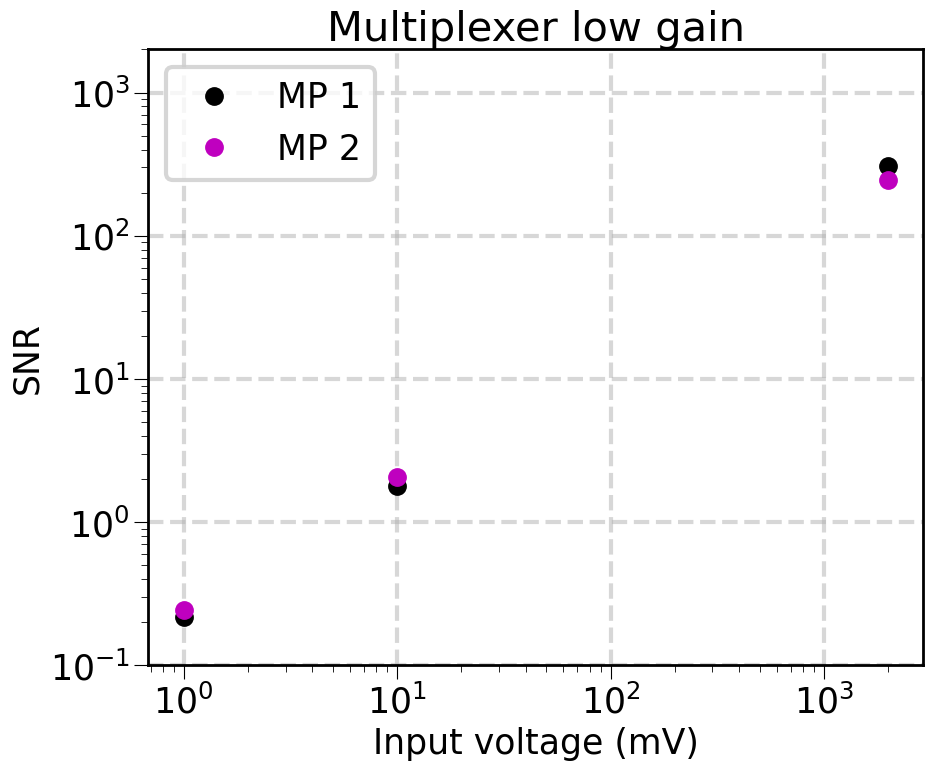

In [65]:
plt.plot(bias_low, n3_lg, "k.", label="MP 1")
plt.plot(bias_low, n4_lg, "m.", label="MP 2")
plt.ylim(.1, 2e3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("SNR")
plt.title("Multiplexer low gain")
plt.legend()
plt.grid()

# High gain multiplexer

In [59]:
a3_hg = []
a4_hg = []
n3_hg = []
n4_hg = []
for s in "s2 s3 s4".split():
    diff1   = a3path / f"C2--{s}_a3_hg--00000.csv"
    diff2   = a3path / f"C3--{s}_a3_hg--00000.csv"
    t, diff = difference(diff1, diff2)
    a3_hg = np.append(a3_hg, integrate_signal(t, diff, *signalwindow))
    n3_hg = np.append(n3_hg, signal_to_noise(t, diff, blinewindow, signalwindow))

    diff1   = a4path / f"C2--{s}_a4_hg--00000.csv"
    diff2   = a4path / f"C3--{s}_a4_hg--00000.csv"
    t, diff = difference(diff1, diff2)
    a4_hg = np.append(a4_hg, integrate_signal(t, diff, *signalwindow))
    n4_hg = np.append(n4_hg, signal_to_noise(t, diff, blinewindow, signalwindow))

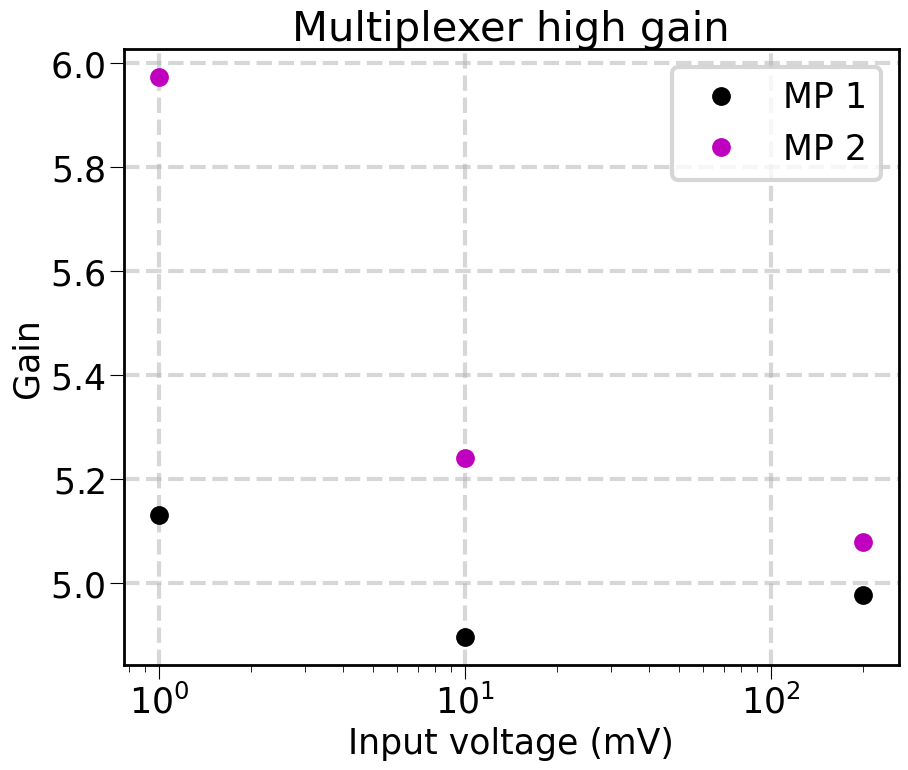

In [60]:
plt.plot(bias_high, a3_hg/signals_high, "k.", label="MP 1")
plt.plot(bias_high, a4_hg/signals_high, "m.", label="MP 2")
plt.xscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("Gain")
plt.title("Multiplexer high gain")
plt.legend()
plt.grid()

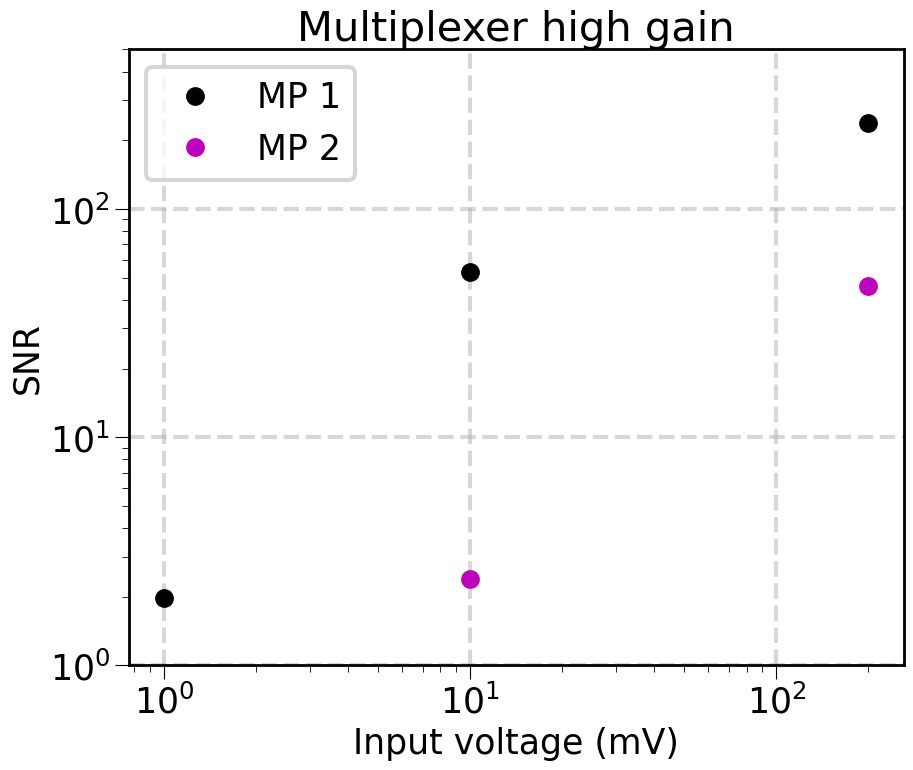

In [67]:
plt.plot(bias_high, n3_hg, "k.", label="MP 1")
plt.plot(bias_high, n4_hg, "m.", label="MP 2")
plt.ylim(1, 5e2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("SNR")
plt.title("Multiplexer high gain")
plt.legend()
plt.grid()

# Two stages

In [72]:
a2s = []
n2s = []
for s in "s2 s3 s4".split():
    filename = s2path / f"C2--{s}_a2_2s--00000.csv"
    t, diff  = read(filename)
    a2s = np.append(a2s, -integrate_signal(t, diff, *shapedwindow))
    n2s = np.append(n2s, -signal_to_noise(t, diff, blinewindow, signalwindow))

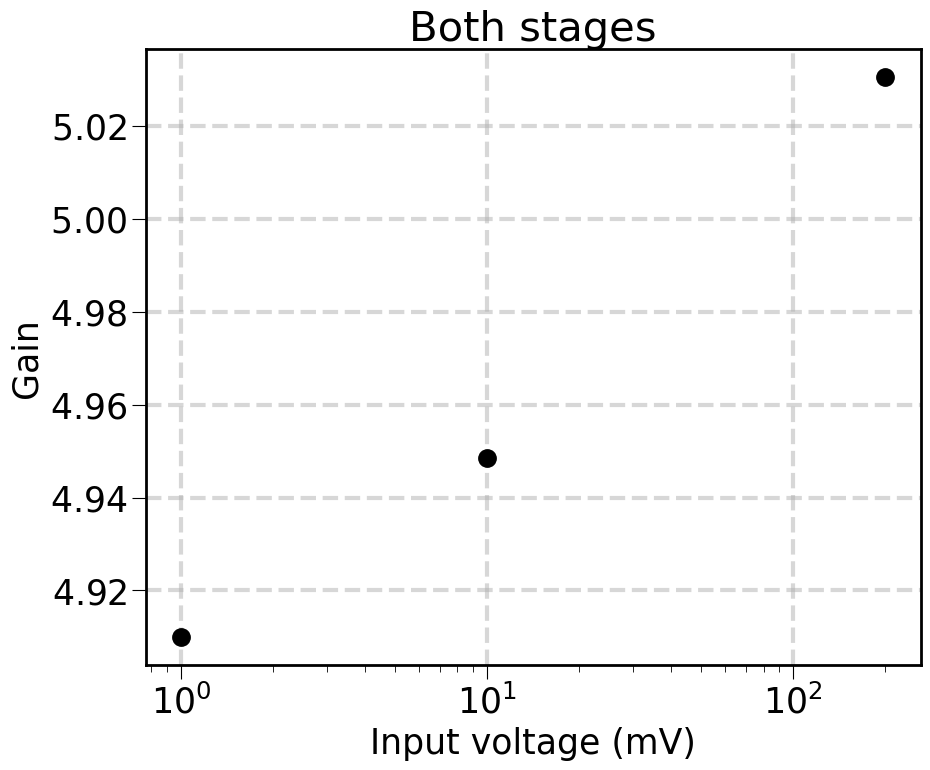

In [73]:
plt.plot(bias_high, a2s/signals_high, "k.")
plt.xscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("Gain")
plt.title("Both stages")
plt.grid()

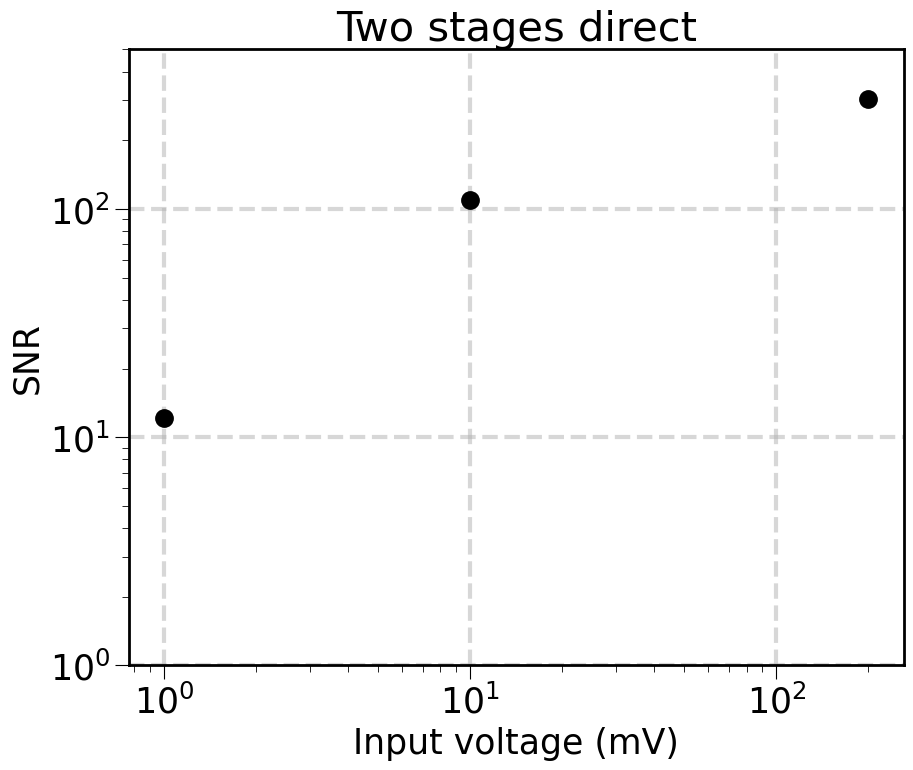

In [74]:
plt.plot(bias_high, n2s, "k.")
plt.ylim(1, 5e2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("SNR")
plt.title("Two stages direct")
plt.grid()

# Impedance match

In [75]:
aim = []
nim = []
for s in "s2 s3 s4".split():
    filename = impath / f"C2--{s}_a2_2s--00000.csv"
    t, diff  = read(filename)
    aim = np.append(aim, -integrate_signal(t, diff, *shapedwindow))
    nim = np.append(nim, -signal_to_noise(t, diff, blinewindow, signalwindow))

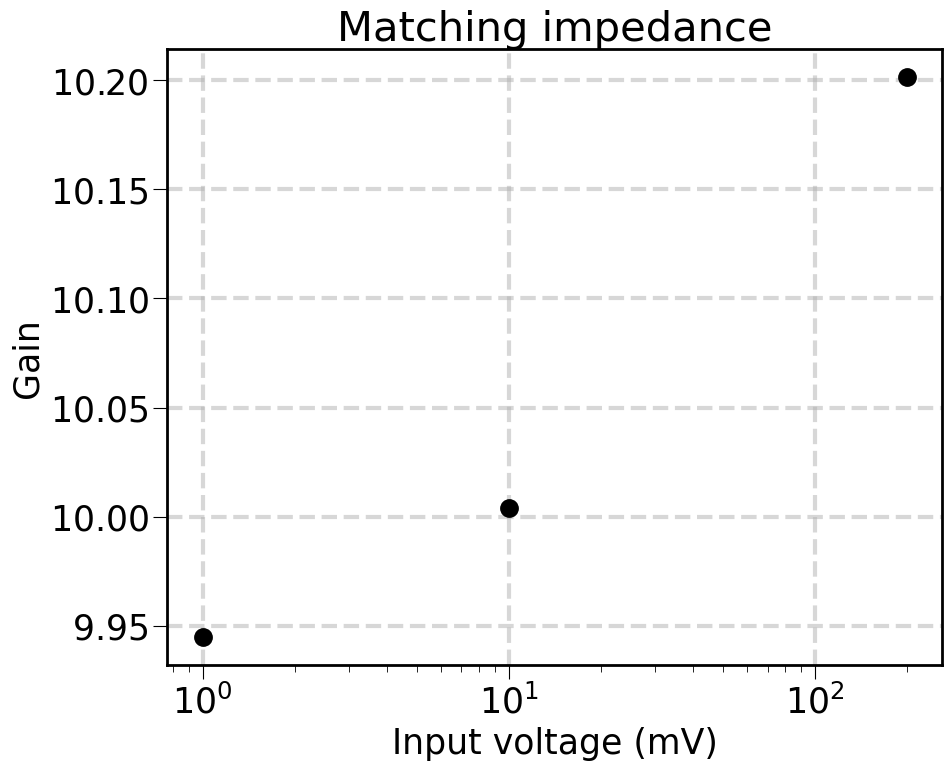

In [76]:
plt.plot(bias_high, aim/signals_high, "k.")
plt.xscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("Gain")
plt.title("Matching impedance")
plt.grid()

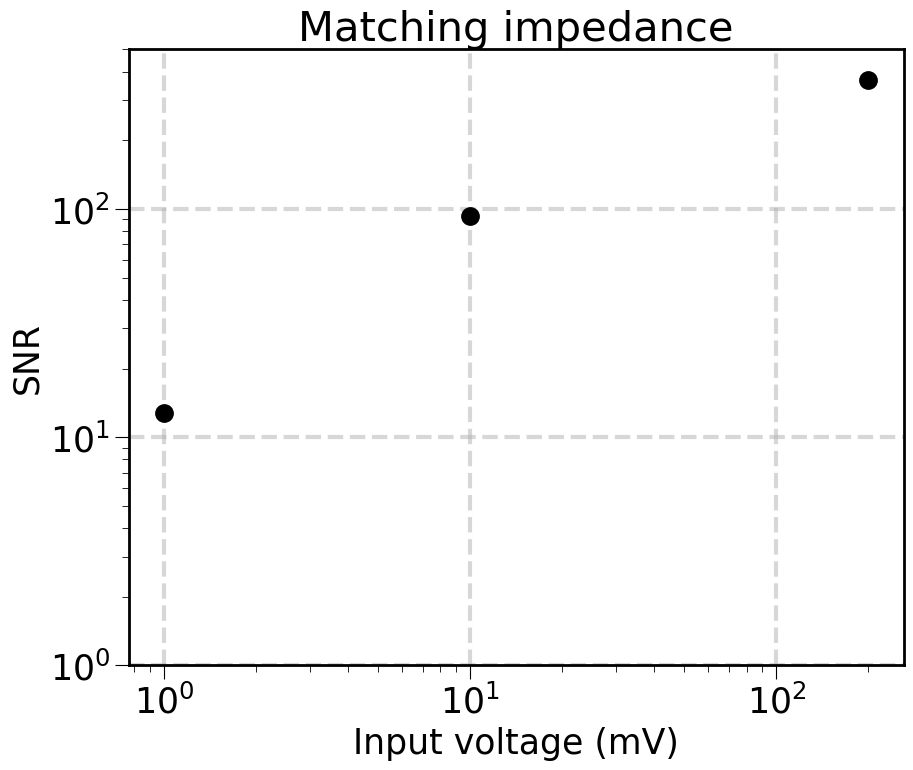

In [77]:
plt.plot(bias_high, nim, "k.")
plt.ylim(1, 5e2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("SNR")
plt.title("Matching impedance")
plt.grid()

# Combining results

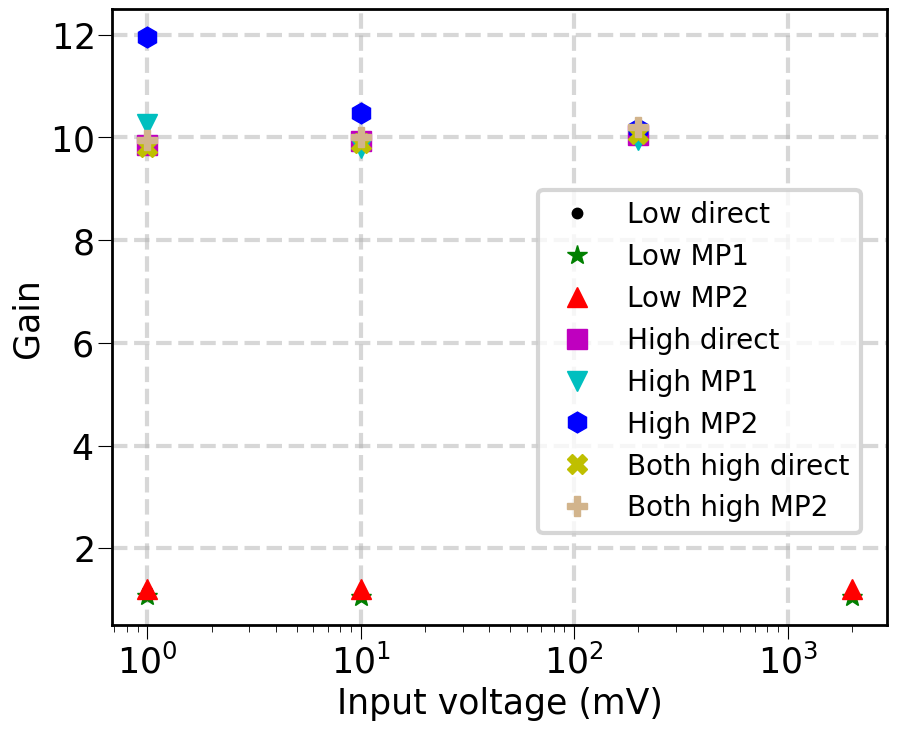

In [89]:
factor = 2 # due to impedance mismatch

plt.plot(bias_low , a1   /signals_low  * factor, ".", c="k"  , ms=15, label="Low direct")
plt.plot(bias_low , a3_lg/signals_low  * factor, "*", c="g"  , ms=15, label="Low MP1")
plt.plot(bias_low , a4_lg/signals_low  * factor, "^", c="r"  , ms=15, label="Low MP2")
plt.plot(bias_high, a2   /signals_high * factor, "s", c="m"  , ms=15, label="High direct")
plt.plot(bias_high, a3_hg/signals_high * factor, "v", c="c"  , ms=15, label="High MP1")
plt.plot(bias_high, a4_hg/signals_high * factor, "h", c="b"  , ms=15, label="High MP2")
plt.plot(bias_high, a2s  /signals_high * factor, "X", c="y"  , ms=15, label="Both high direct")
plt.plot(bias_high, aim  /signals_high         , "P", c="tan", ms=15, label="Both high MP2")

plt.legend(fontsize=20, loc=(.55, .15))
plt.xscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("Gain")
plt.grid()

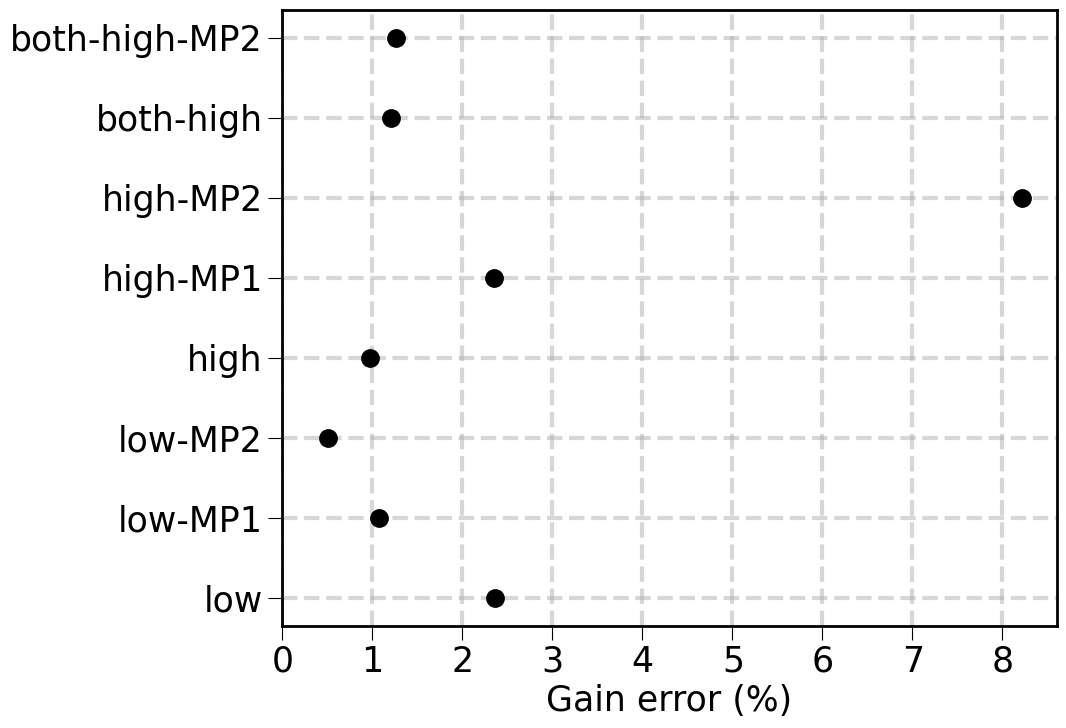

In [79]:
configurations = "low low-MP1 low-MP2 high high-MP1 high-MP2 both-high both-high-MP2".split()
gain           = ( a1   /signals_low  * factor
                 , a3_lg/signals_low  * factor
                 , a4_lg/signals_low  * factor
                 , a2   /signals_high * factor
                 , a3_hg/signals_high * factor
                 , a4_hg/signals_high * factor
                 , a2s  /signals_high * factor
                 , aim  /signals_high
                 )
gain_error     = ((g.max() - g.min())*100/2/g.mean() for g in gain)
gain           = np.array(gain)
gain_error     = np.array(list(gain_error))
#plt.plot(configurations, gain_error, ".k")
plt.plot(gain_error, configurations, ".k")
plt.xlabel("Gain error (%)")
plt.xticks(np.arange(9))
plt.xlim(0)
plt.grid()

In [80]:
pd.DataFrame(dict(gain=gain.mean(axis=1), error=gain_error), index=configurations)

,gain,error
low,1.148285,2.370273
low-MP1,1.051359,1.080948
low-MP2,1.201702,0.513862
high,9.945114,0.982523
high-MP1,10.003851,2.359827
high-MP2,10.862316,8.216270
both-high,9.925905,1.214670
both-high-MP2,10.049997,1.275874


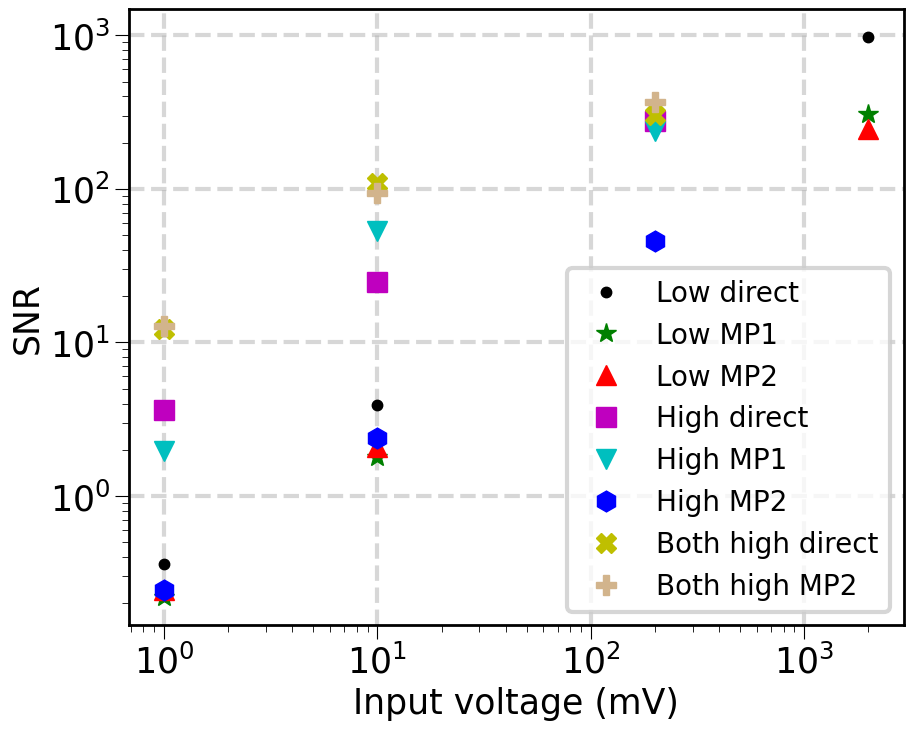

In [85]:
factor = 2 # due to impedance mismatch

plt.plot(bias_low , n1   , ".", c="k"  , ms=15, label="Low direct")
plt.plot(bias_low , n3_lg, "*", c="g"  , ms=15, label="Low MP1")
plt.plot(bias_low , n4_lg, "^", c="r"  , ms=15, label="Low MP2")
plt.plot(bias_high, n2   , "s", c="m"  , ms=15, label="High direct")
plt.plot(bias_high, n3_hg, "v", c="c"  , ms=15, label="High MP1")
plt.plot(bias_high, n4_hg, "h", c="b"  , ms=15, label="High MP2")
plt.plot(bias_high, n2s  , "X", c="y"  , ms=15, label="Both high direct")
plt.plot(bias_high, nim  , "P", c="tan", ms=15, label="Both high MP2")

plt.legend(fontsize=20, loc=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input voltage (mV)")
plt.ylabel("SNR")
plt.grid()

# Waveform comparison

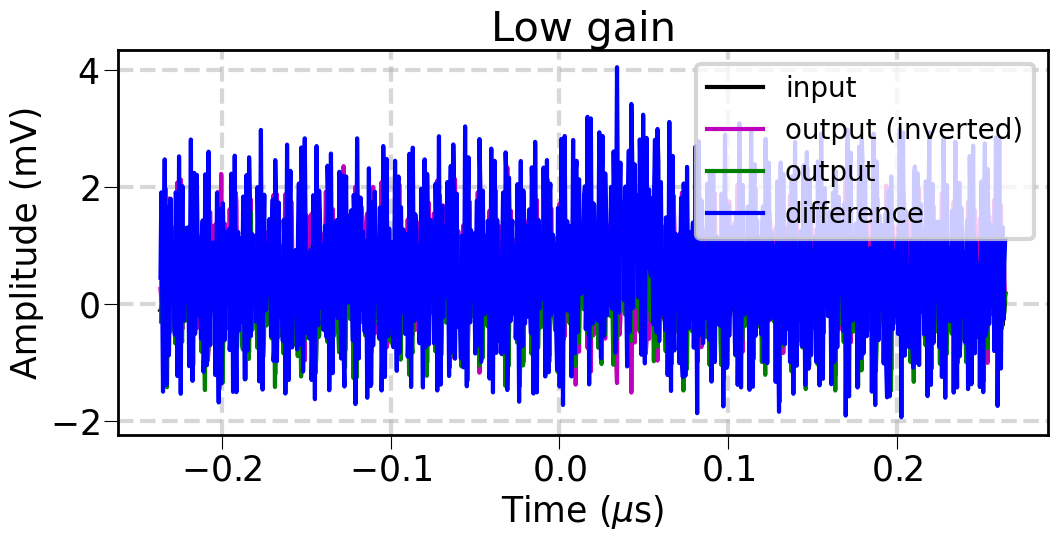

In [45]:
plt.figure(figsize=(12, 5))
t, a = read(signalpath / "C4--S2--00000.csv")
plt.plot(t*1e6, a*1e3, label="input")
t, a = read(a1path / "C2--s2_a1--00000.csv")
plt.plot(t*1e6, a*1e3 - 1456, label="output (inverted)")
t, a = read(a1path / "C3--s2_a1--00000.csv")
plt.plot(t*1e6, a*1e3 - 1015, label="output")
t, a = difference(a1path / "C2--s2_a1--00000.csv", a1path / "C3--s2_a1--00000.csv")
plt.plot(t*1e6, a*1e3 + 442, label="difference")
plt.legend(fontsize=20)
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Amplitude (mV)")
plt.title("Low gain")
plt.grid()

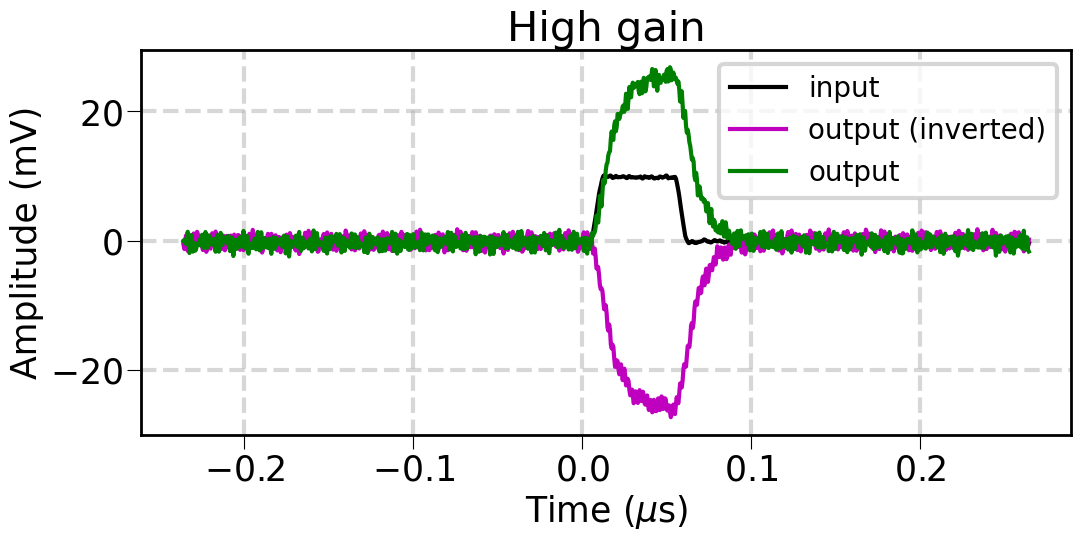

In [27]:
plt.figure(figsize=(12, 5))
t, a = read(signalpath / "C4--S3--00000.csv")
plt.plot(t*1e6, a*1e3, label="input")
t, a = read(a2path / "C2--s3_a2--00000.csv")
plt.plot(t*1e6, a*1e3 - 1951, label="output (inverted)")
t, a = read(a2path / "C3--s3_a2--00000.csv")
plt.plot(t*1e6, a*1e3 -  522, label="output")
plt.legend(fontsize=20)
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Amplitude (mV)")
plt.title("High gain")
plt.grid()

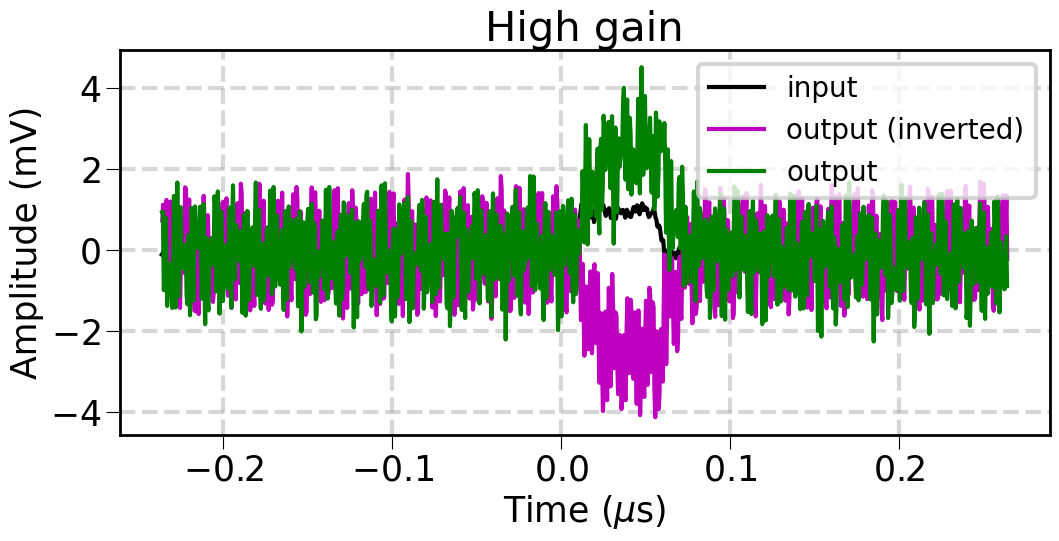

In [28]:
plt.figure(figsize=(12, 5))
t, a = read(signalpath / "C4--S2--00000.csv")
plt.plot(t*1e6, a*1e3, label="input")
t, a = read(a2path / "C2--s2_a2--00000.csv")
plt.plot(t*1e6, a*1e3 - 1951, label="output (inverted)")
t, a = read(a2path / "C3--s2_a2--00000.csv")
plt.plot(t*1e6, a*1e3 -  522, label="output")
plt.legend(fontsize=20)
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Amplitude (mV)")
plt.title("High gain")
plt.grid()

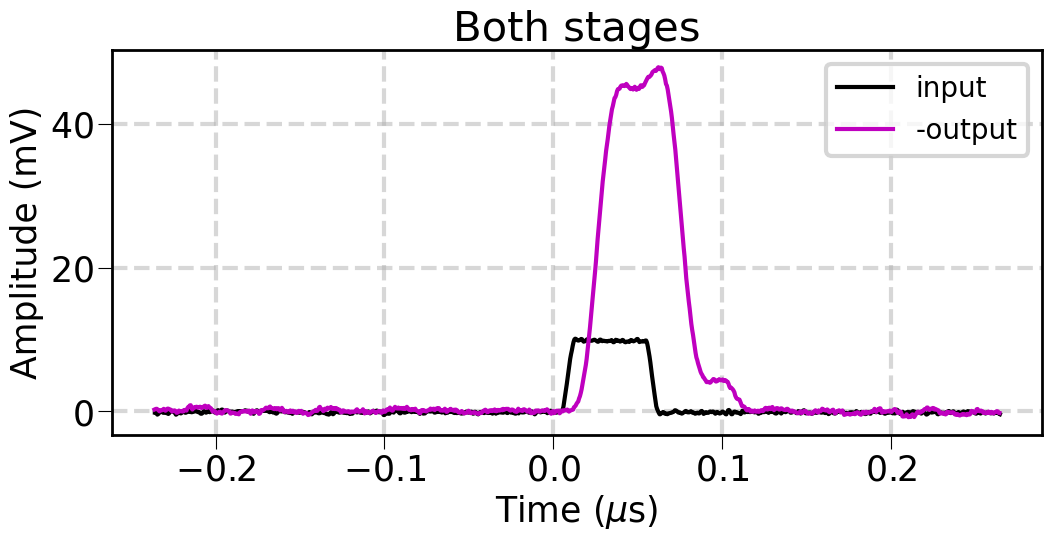

In [29]:
plt.figure(figsize=(12, 5))
t, a = read(signalpath / "C4--S3--00000.csv")
plt.plot(t*1e6, a*1e3, label="input")
t, a = read(s2path / "C2--s3_a2_2s--00000.csv")
plt.plot(t*1e6, -a*1e3, label="-output")
plt.legend(fontsize=20)
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Amplitude (mV)")
plt.title("Both stages")
plt.grid()

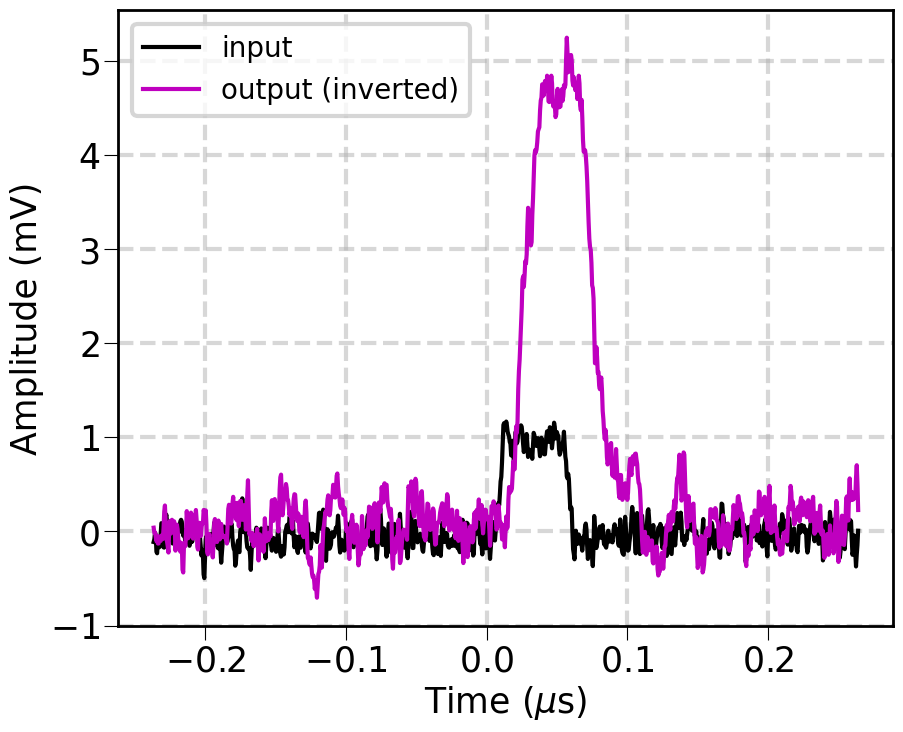

In [35]:
t, a = read(signalpath / "C4--S2--00000.csv")
plt.plot(t*1e6, a*1e3, label="input")
t, a = read(s2path / "C2--s2_a2_2s--00000.csv")
plt.plot(t*1e6, -a*1e3, label="output (inverted)")
plt.legend(fontsize=20)
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

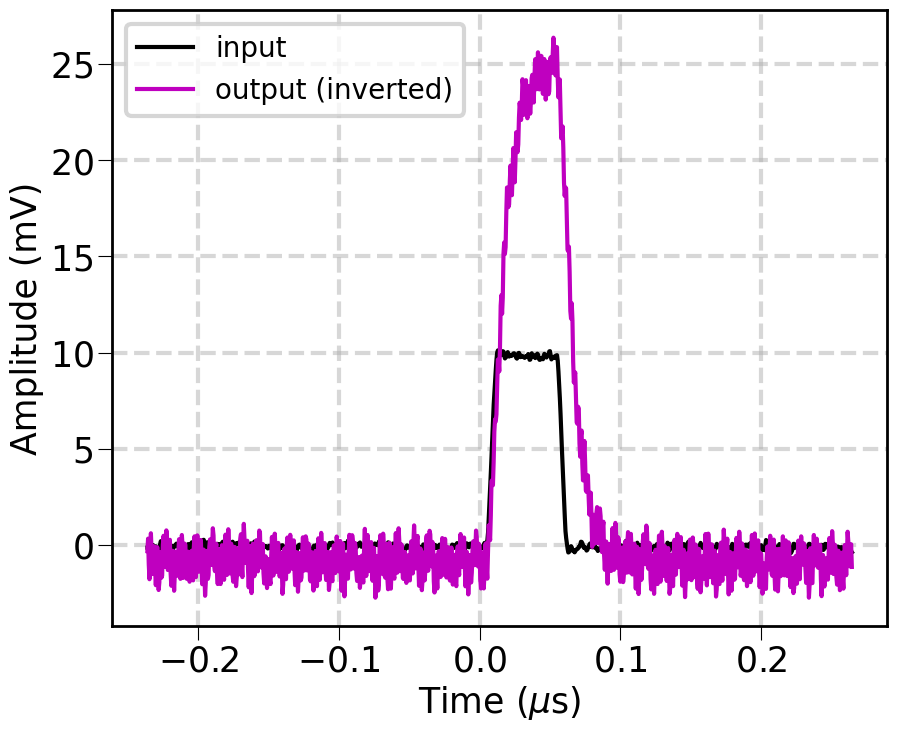

In [31]:
t, a = read(signalpath / "C4--S3--00000.csv")
plt.plot(t*1e6, a*1e3, label="input")
t, a = read(a2path / "C2--s3_a2--00000.csv")
plt.plot(t*1e6, -a*1e3 + 1950, label="output (inverted)")
plt.legend(fontsize=20)
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

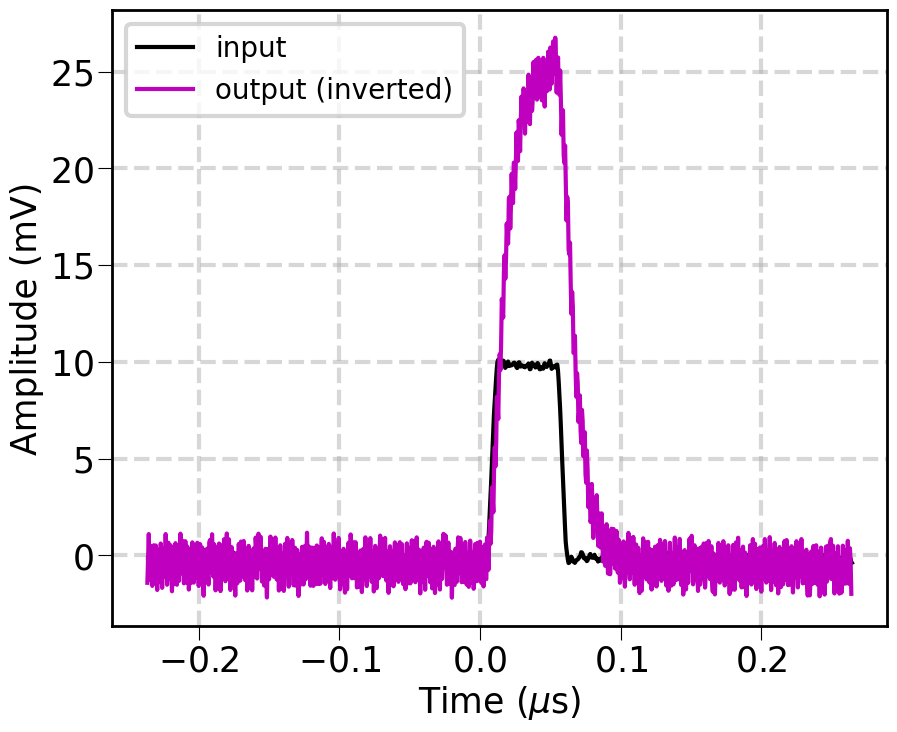

In [32]:
t, a = read(signalpath / "C4--S3--00000.csv")
plt.plot(t*1e6, a*1e3, label="input")
t, a = read(a3path / "C2--s3_a3_hg--00000.csv")
plt.plot(t*1e6, -a*1e3 + 1951, label="output (inverted)")
plt.legend(fontsize=20)
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Amplitude (mV)")
plt.grid()